In [ ]:
!pip install stable-baselines3[extra]
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git
!pip install websockets>=15.0.0 --quiet
!pip install transformers --quiet
!pip install newsapi-python --quiet
!pip install alpaca-py --quiet
!pip install gymnasium --quiet
!pip install polygon-api-client --quiet

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import pkg_resources
import os
import pickle
import math
import time
import subprocess
from datetime import timedelta, date, datetime
from transformers import BertTokenizer, BertForSequenceClassification

# Alpaca imports
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce

# Polygon import
from polygon import RESTClient

import torch as th
import torch.nn as nn
import stable_baselines3
import finrl
import gymnasium as gym
from gymnasium import spaces

import sys
sys.path.append('.')
import importlib
import utils
importlib.reload(utils)
from utils import (
    prepare_df, compute_metrics, compute_rolling_metrics,
    plot_metrics, compute_buy_and_hold, overfitting_check,
    check_degenerate_policy, check_lookahead_bias,
    regime_analysis, run_full_evaluation_transformer
)
print("utils.py loaded ✅")

from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import (
    EvalCallback,
    StopTrainingOnNoModelImprovement,
)
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.config import INDICATORS
import yfinance as yf

%matplotlib inline
plt.close('all')

print(f"SB3 Version:    {stable_baselines3.__version__}")
print(f"FinRL Version:  {pkg_resources.get_distribution('finrl').version}")

if th.backends.mps.is_available():
    DEVICE = th.device('mps')
    print("MPS (Apple Metal GPU) available — using GPU ✓")
elif th.cuda.is_available():
    DEVICE = th.device('cuda')
    print(f"CUDA GPU available — using {th.cuda.get_device_name(0)} ✓")
else:
    DEVICE = th.device('cpu')
    print("No GPU found — falling back to CPU")

print(f"Active device: {DEVICE}")

/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/ipykernel_10349/2150208851.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


utils.py loaded ✅
SB3 Version:    2.8.0a2
FinRL Version:  0.3.8
MPS (Apple Metal GPU) available — using GPU ✓
Active device: mps


In [ ]:
# ============================================================
# CELL 2a — Alpaca + Polygon Configuration
# ============================================================
ALPACA_API_KEY    = os.environ.get('ALPACA_API_KEY', 'YOUR_API_KEY')
ALPACA_SECRET_KEY = os.environ.get('ALPACA_SECRET_KEY', 'YOUR_API_KEY')
POLYGON_API_KEY   = os.environ.get('POLYGON_API_KEY', 'YOUR_API_KEY')
PAPER_TRADING     = True

data_client    = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)
trading_client = TradingClient(ALPACA_API_KEY, ALPACA_SECRET_KEY,
                               paper=PAPER_TRADING)
polygon_client = RESTClient(api_key=POLYGON_API_KEY)

account = trading_client.get_account()
print(f"Alpaca connected ✅")
print(f"  Status:        {account.status}")
print(f"  Buying power:  ${float(account.buying_power):,.2f}")
print(f"  Cash:          ${float(account.cash):,.2f}")
print(f"  Paper trading: {PAPER_TRADING}")
print(f"Polygon client initialised ✅")

Alpaca connected ✅
  Status:        AccountStatus.ACTIVE
  Buying power:  $200,000.00
  Cash:          $100,000.00
  Paper trading: True
Polygon client initialised ✅


In [3]:
# ============================================================
# CELL 2b_alpaca — Alpaca Data Fetcher
# ============================================================
def fetch_alpaca_data(tickers: list[str],
                      start_date: str,
                      end_date: str) -> pd.DataFrame:
    print(f"Fetching Alpaca data: {start_date} → {end_date} "
          f"for {len(tickers)} tickers...")

    request_params = StockBarsRequest(
        symbol_or_symbols=tickers,
        timeframe=TimeFrame.Day,
        start=start_date,
        end=end_date,
        adjustment='all'
    )

    bars = data_client.get_stock_bars(request_params)
    df   = bars.df.reset_index()

    df = df.rename(columns={
        'symbol':    'tic',
        'timestamp': 'date',
    })

    df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')
    df = df.sort_values(['date', 'tic']).reset_index(drop=True)
    df['day'] = df.groupby('tic').cumcount()
    df = df[['date', 'open', 'high', 'low', 'close', 'volume', 'tic', 'day']]

    print(f"Fetched — shape: {df.shape}")
    print(f"Date range: {df['date'].min()} → {df['date'].max()}")
    return df


def fetch_alpaca_latest_prices(tickers: list[str]) -> pd.Series:
    request_params = StockBarsRequest(
        symbol_or_symbols=tickers,
        timeframe=TimeFrame.Day,
        start=(date.today() - timedelta(days=5)).strftime('%Y-%m-%d'),
        end=date.today().strftime('%Y-%m-%d'),
        adjustment='all'
    )
    bars = data_client.get_stock_bars(request_params)
    df   = bars.df.reset_index()
    df   = df.rename(columns={'symbol': 'tic', 'timestamp': 'date'})
    df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')
    return df.sort_values('date').groupby('tic').last()['close']

In [4]:
# ============================================================
# CELL 2b — FinBERT + Polygon Sentiment Utilities
# ============================================================
SENTIMENT_DEVICE = 'cpu'

print("Loading FinBERT...")
tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
finbert   = BertForSequenceClassification.from_pretrained('ProsusAI/finbert')
finbert   = finbert.to(SENTIMENT_DEVICE)
finbert.eval()
print("FinBERT loaded ✓")


def score_headlines(headlines: list) -> float:
    """
    Run headlines through FinBERT.
    Returns float in [-1, +1]: positive = bullish, negative = bearish.
    """
    if not headlines:
        return 0.0
    scores = []
    for text in headlines:
        inputs = tokenizer(
            text, return_tensors='pt',
            truncation=True, max_length=128, padding=True
        ).to(SENTIMENT_DEVICE)
        with th.no_grad():
            logits = finbert(**inputs).logits
            probs  = th.softmax(logits, dim=1).squeeze()
        scores.append(probs[0].item() - probs[1].item())
    return float(np.mean(scores))


def fetch_sentiment_polygon(ticker: str,
                             start_date: str,
                             end_date: str) -> pd.Series:
    """
    Fetch news headlines for a ticker from Polygon.io and score
    each day with FinBERT.

    Key advantages over NewsAPI:
      - Full historical coverage back to 2015+ (no 30-day limit)
      - Proper per-ticker date filtering
      - Financial news sources only — more relevant signal
      - Up to 1000 articles per request with automatic pagination
    """
    daily_headlines: dict = {}

    try:
        for article in polygon_client.list_ticker_news(
            ticker,
            published_utc_gte=start_date,
            published_utc_lte=end_date,
            limit=1000,
            sort='published_utc',
            order='asc'
        ):
            try:
                pub_ts   = pd.Timestamp(article.published_utc)
                date_str = pub_ts.strftime('%Y-%m-%d')
                title    = getattr(article, 'title', '') or ''
                if title:
                    daily_headlines.setdefault(date_str, []).append(title)
            except Exception:
                continue

    except Exception as e:
        print(f"  Warning: Polygon error for {ticker}: {e}")

    dated_scores = {
        date_str: score_headlines(headlines)
        for date_str, headlines in daily_headlines.items()
    }

    return pd.Series(dated_scores, name=ticker)


def build_sentiment_df(tickers: list, start_date: str,
                        end_date: str) -> pd.DataFrame:
    """
    Build sentiment DataFrame for all tickers over the full date range.
    With Polygon this covers the complete 2020-2024 training period —
    no more mostly-zero sentiment during training.

    Note: Polygon free tier = 5 calls/min.
    A 12-second sleep between tickers respects this limit.
    First run takes ~30-45 mins for 30 tickers x 4 years.
    Subsequent runs load from cache instantly.
    """
    print(f"Fetching Polygon sentiment for {len(tickers)} tickers "
          f"({start_date} → {end_date})...")
    series_list = []

    for i, ticker in enumerate(tickers):
        print(f"  [{i+1}/{len(tickers)}] {ticker}    ", end='\r')
        s = fetch_sentiment_polygon(ticker, start_date, end_date)
        series_list.append(s)
        # Respect Polygon free tier rate limit (5 calls/min)
        time.sleep(12)

    df_sent = pd.DataFrame(series_list).T
    df_sent.index.name = 'date'
    df_sent = df_sent.sort_index().ffill().fillna(0.0)

    print(f"\nDone. Shape: {df_sent.shape}")
    print(f"Non-zero entries: {(df_sent != 0).sum().sum():,}")
    return df_sent


def build_sentiment_df_cached(tickers: list, start_date: str,
                               end_date: str,
                               cache_file: str = 'sentiment_cache.pkl') -> pd.DataFrame:
    """
    Cache wrapper — historical data (train/test) never goes stale
    so it is cached permanently. Live data (future) refreshes daily.
    """
    today_str     = date.today().strftime('%Y-%m-%d')
    is_historical = end_date < today_str

    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            cached = pickle.load(f)
        if is_historical or cached.get('fetch_date') == today_str:
            print(f"✅ Loaded from cache: {cache_file}")
            return cached['df']
        print(f"Cache stale — fetching fresh from Polygon...")
    else:
        print(f"No cache found — fetching from Polygon...")

    df_sent = build_sentiment_df(tickers, start_date, end_date)

    with open(cache_file, 'wb') as f:
        pickle.dump({
            'fetch_date': today_str,
            'start_date': start_date,
            'end_date':   end_date,
            'df':         df_sent
        }, f)
    print(f"✅ Cached to {cache_file}")
    return df_sent

Loading FinBERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2510.65it/s, Materializing param=classifier.weight]                                      
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded ✓


In [5]:
# ============================================================
# CELL 3 — Download Data via Alpaca + Macro Features
# ============================================================
TICKERS = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'PYPL', 'ADBE', 'NFLX',
    'INTC', 'CSCO', 'PEP',  'AVGO', 'COST', 'QCOM', 'CMCSA','TMUS', 'TXN',  'AMGN',
    'HON',  'SBUX', 'INTU', 'MDLZ', 'GILD', 'ISRG', 'ADP',  'BKNG', 'VRTX', 'ADI'
]
NUM_STOCKS = len(TICKERS)

df_raw_train = fetch_alpaca_data(TICKERS, '2020-01-01', '2024-01-01')
df_raw_test  = fetch_alpaca_data(TICKERS, '2024-01-01', '2025-01-01')

fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS,
    use_vix=False,
    use_turbulence=False
)

df_train_raw = fe.preprocess_data(df_raw_train)
df_test_raw  = fe.preprocess_data(df_raw_test)
print(f"Train raw shape: {df_train_raw.shape}")
print(f"Test raw shape:  {df_test_raw.shape}")

# ── Macro features ────────────────────────────────────────────
def fetch_macro_features(start_date: str, end_date: str) -> pd.DataFrame:
    """
    Fetch daily macro context features via yfinance.
    Returns pct_change so all features are on a normalised scale.
    Gives the model market-wide context so it can learn to be
    defensive during high-VIX or broad market sell-off periods.
    """
    macro_tickers = {
        'VIX': '^VIX',
        'TNX': '^TNX',
        'SPY': 'SPY',
        'QQQ': 'QQQ',
        'XLK': 'XLK',
    }
    frames = {}
    for name, ticker in macro_tickers.items():
        try:
            data = yf.download(ticker, start=start_date,
                               end=end_date, progress=False,
                               auto_adjust=True)
            close = data['Close']
            if isinstance(close, pd.DataFrame):
                close = close.iloc[:, 0]
            frames[name] = close.pct_change().fillna(0)
        except Exception as e:
            print(f"  Warning: Could not fetch {name} ({ticker}): {e}")

    if not frames:
        print("⚠️  No macro features fetched — returning empty DataFrame")
        return pd.DataFrame()

    macro_df = pd.concat(frames, axis=1)
    macro_df.columns = list(frames.keys())
    macro_df.index   = pd.to_datetime(macro_df.index).strftime('%Y-%m-%d')
    macro_df.index.name = 'date'
    macro_df = macro_df.fillna(0.0)

    print(f"Macro features fetched — shape: {macro_df.shape}")
    print(f"  Features: {list(macro_df.columns)}")
    return macro_df

print("Fetching macro features for training period...")
df_macro_train = fetch_macro_features('2020-01-01', '2024-01-01')

print("Fetching macro features for test period...")
df_macro_test  = fetch_macro_features('2024-01-01', '2025-01-01')

Fetching Alpaca data: 2020-01-01 → 2024-01-01 for 30 tickers...
Fetched — shape: (30180, 8)
Date range: 2020-01-02 → 2023-12-29
Fetching Alpaca data: 2024-01-01 → 2025-01-01 for 30 tickers...
Fetched — shape: (7560, 8)
Date range: 2024-01-02 → 2024-12-31
Successfully added technical indicators
Successfully added technical indicators
Train raw shape: (30180, 16)
Test raw shape:  (7560, 16)
Fetching macro features for training period...
Macro features fetched — shape: (1006, 5)
  Features: ['VIX', 'TNX', 'SPY', 'QQQ', 'XLK']
Fetching macro features for test period...
Macro features fetched — shape: (252, 5)
  Features: ['VIX', 'TNX', 'SPY', 'QQQ', 'XLK']


In [6]:
# ============================================================
# CELL 2c — Fetch Sentiment Scores via Polygon
# ============================================================
# With Polygon we fetch the FULL training and test date ranges.
# No more 30-day limitation — training sentiment will be real
# scores for all of 2020-2024, not mostly zeros.
#
# First run: ~30-45 minutes (rate-limited to 5 calls/min)
# Subsequent runs: instant (loaded from cache)

TRAIN_START = '2020-01-01'
TRAIN_END   = '2024-01-01'
TEST_START  = '2024-01-01'
TEST_END    = '2025-01-01'

print("Fetching training sentiment via Polygon (2020-2024)...")
print("First run takes ~30-45 mins — cached permanently after that.")
df_sent_train = build_sentiment_df_cached(
    TICKERS,
    TRAIN_START,
    TRAIN_END,
    cache_file='sentiment_train_transformer_30stock_10k.pkl'
)

print("\nFetching test sentiment via Polygon (2024-2025)...")
df_sent_test = build_sentiment_df_cached(
    TICKERS,
    TEST_START,
    TEST_END,
    cache_file='sentiment_test_transformer_30stock_10k.pkl'
)

total_train   = df_sent_train.size
nonzero_train = (df_sent_train != 0).sum().sum()
nonzero_test  = (df_sent_test  != 0).sum().sum()
coverage_pct  = nonzero_train / total_train * 100

print(f"\nSentiment coverage summary:")
print(f"  Train non-zero: {nonzero_train:,} / {total_train:,} ({coverage_pct:.1f}%)")
print(f"  Test  non-zero: {nonzero_test:,}")
print(f"\nTrain sentiment sample (real scores across 2020-2024):")
print(df_sent_train.tail())

Fetching training sentiment via Polygon (2020-2024)...
First run takes ~30-45 mins — cached permanently after that.
No cache found — fetching from Polygon...
Fetching Polygon sentiment for 30 tickers (2020-01-01 → 2024-01-01)...
  [30/30] ADI      
Done. Shape: (1158, 30)
Non-zero entries: 32,709
✅ Cached to sentiment_train_transformer_30stock_10k.pkl

Fetching test sentiment via Polygon (2024-2025)...
No cache found — fetching from Polygon...
Fetching Polygon sentiment for 30 tickers (2024-01-01 → 2025-01-01)...
  [30/30] ADI      
Done. Shape: (366, 30)
Non-zero entries: 10,968
✅ Cached to sentiment_test_transformer_30stock_10k.pkl

Sentiment coverage summary:
  Train non-zero: 32,709 / 34,740 (94.2%)
  Test  non-zero: 10,968

Train sentiment sample (real scores across 2020-2024):
                AAPL      MSFT     GOOGL      AMZN      META      TSLA  \
date                                                                     
2023-12-28  0.122119  0.095102  0.120230  0.151735  0.3066

In [7]:
import importlib
import utils
importlib.reload(utils)
from utils import (
    prepare_df, compute_metrics, compute_rolling_metrics,
    plot_metrics, compute_buy_and_hold, overfitting_check,
    check_degenerate_policy, check_lookahead_bias,
    regime_analysis, run_full_evaluation_transformer
)
print("utils.py reloaded ✅")

utils.py reloaded ✅


In [8]:
# ============================================================
# CELL 4 — Clean, Validate & Merge Sentiment + Macro Features
# ============================================================
MACRO_FEATURES       = ['VIX', 'TNX', 'SPY', 'QQQ', 'XLK']
INDICATORS_WITH_SENT = INDICATORS + ['sentiment'] + MACRO_FEATURES
INDICATORS_COUNT     = len(INDICATORS_WITH_SENT)

# Process train first
df_train = prepare_df(df_train_raw, df_sent_train, df_macro_train)

# Lock in train tickers
TRAIN_TICKERS  = sorted(df_train['tic'].unique().tolist())
TRAIN_N_STOCKS = len(TRAIN_TICKERS)
print(f"Train tickers: {TRAIN_N_STOCKS}")

# Filter test to train tickers before prepare_df
df_test_raw_filtered = df_test_raw[
    df_test_raw['tic'].isin(TRAIN_TICKERS)
].reset_index(drop=True)
df_test = prepare_df(df_test_raw_filtered, df_sent_test,
                     df_macro_test)

# Set globals from train
TICKERS    = TRAIN_TICKERS
NUM_STOCKS = TRAIN_N_STOCKS

print(f"\nAll required columns present in df_train:")
for ind in INDICATORS_WITH_SENT:
    present = ind in df_train.columns
    print(f"  {ind}: {'✅' if present else '❌ MISSING'}")

print(f"\nTrain ready — {df_train['date'].nunique()} trading days")
print(f"Test  ready — {df_test['date'].nunique()} trading days")
print(f"Tickers:      {NUM_STOCKS}")

Using 30 tickers with complete data
Sentiment merged — non-zero rows: 23141 / 30180
Look-ahead lag applied — trading on t uses news from t-1
Macro features merged — 5 features: ['VIX', 'TNX', 'SPY', 'QQQ', 'XLK']
Index OK — starts at 0, ends at 1005
Train tickers: 30
Using 30 tickers with complete data
Sentiment merged — non-zero rows: 7496 / 7560
Look-ahead lag applied — trading on t uses news from t-1
Macro features merged — 5 features: ['VIX', 'TNX', 'SPY', 'QQQ', 'XLK']
Index OK — starts at 0, ends at 251

All required columns present in df_train:
  macd: ✅
  boll_ub: ✅
  boll_lb: ✅
  rsi_30: ✅
  cci_30: ✅
  dx_30: ✅
  close_30_sma: ✅
  close_60_sma: ✅
  sentiment: ✅
  VIX: ✅
  TNX: ✅
  SPY: ✅
  QQQ: ✅
  XLK: ✅

Train ready — 1006 trading days
Test  ready — 252 trading days
Tickers:      30


In [9]:
# ============================================================
# CELL 5 — Cross-Stock Transformer + PPO + All Improvements
# ============================================================
from stable_baselines3.common.callbacks import (
    CheckpointCallback,
    CallbackList,
    BaseCallback,
)
# STATE_SPACE, NUM_STOCKS, INDICATORS_COUNT set in Cell 4 — do not recalculate
INDICATORS_START_IDX = 1 + NUM_STOCKS + NUM_STOCKS
STATE_SPACE          = INDICATORS_START_IDX + (NUM_STOCKS * INDICATORS_COUNT)
LOOKBACK_WINDOW      = 10


# ── Learning rate schedule ────────────────────────────────────
def linear_schedule(initial_value: float):
    """
    Linearly decays LR to 0 over training.
    Prevents the policy degradation seen in previous runs where
    a fixed LR kept updating a policy that had already converged.
    """
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value
    return func


# ── Positional Encoding ───────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 100,
                 dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = th.zeros(max_len, d_model)
        position = th.arange(0, max_len).unsqueeze(1).float()
        div_term = th.exp(
            th.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = th.sin(position * div_term)
        pe[:, 1::2] = th.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# ── Cross-Stock Transformer ───────────────────────────────────
class CrossStockTransformerFinRL(BaseFeaturesExtractor):
    """
    Two-stage transformer architecture:

    Stage 1 — Temporal attention (per stock):
      Each stock attends over its own history.
      With Polygon sentiment, learns patterns like:
        'NVDA has had 5 days of bullish news before a breakout'
        'AAPL sentiment turned negative 3 days before earnings miss'

    Stage 2 — Cross-stock attention (all stocks simultaneously):
      All stocks attend over each other.
      With real sentiment data, learns patterns like:
        'negative NVDA sentiment predicts AMD/AVGO moves'
        'high VIX + negative SPY predicts broad sell-off'

    This is the architecture that most benefits from full
    historical sentiment — it was previously operating blind.
    """
    def __init__(
        self,
        observation_space,
        features_dim:    int   = 128,
        n_stocks:        int   = NUM_STOCKS,
        n_indicators:    int   = INDICATORS_COUNT,
        d_model:         int   = 64,
        nhead:           int   = 4,
        num_layers:      int   = 2,
        dim_feedforward: int   = 256,
        dropout:         float = 0.1,
        lookback:        int   = LOOKBACK_WINDOW,
    ):
        super().__init__(observation_space, features_dim)
        self.lookback     = lookback
        self.n_stocks     = n_stocks
        self.n_indicators = n_indicators
        self.d_model      = d_model

        per_stock_dim = 2 + n_indicators

        self.stock_projection = nn.Sequential(
            nn.Linear(per_stock_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU()
        )

        self.pos_encoder = PositionalEncoding(
            d_model, max_len=lookback + 1, dropout=dropout
        )

        temporal_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.temporal_transformer = nn.TransformerEncoder(
            temporal_layer, num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )

        cross_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.cross_stock_transformer = nn.TransformerEncoder(
            cross_layer, num_layers=1,
            norm=nn.LayerNorm(d_model)
        )

        self.fc = nn.Sequential(
            nn.Linear(d_model * n_stocks, features_dim),
            nn.LayerNorm(features_dim),
            nn.ReLU()
        )

    def forward(self, observations: th.Tensor) -> th.Tensor:
        batch_size = observations.shape[0]
        single_dim = observations.shape[1] // self.lookback

        seq = observations.view(batch_size, self.lookback, single_dim)

        prices     = seq[:, :, 1:1+self.n_stocks]
        shares     = seq[:, :, 1+self.n_stocks:1+2*self.n_stocks]
        start_idx  = 1 + 2 * self.n_stocks
        indicators = seq[:, :, start_idx:].view(
            batch_size, self.lookback, self.n_stocks, self.n_indicators
        )

        prices_exp  = prices.unsqueeze(-1)
        shares_exp  = shares.unsqueeze(-1)
        stock_feats = th.cat([prices_exp, shares_exp, indicators], dim=-1)

        b, t, s, f  = stock_feats.shape
        stock_feats = self.stock_projection(
            stock_feats.view(b * t * s, f)
        ).view(b, t, s, self.d_model)

        # Stage 1: temporal attention
        stock_feats = stock_feats.permute(0, 2, 1, 3)
        stock_feats = stock_feats.reshape(b * s, t, self.d_model)
        stock_feats = self.pos_encoder(stock_feats)
        stock_feats = self.temporal_transformer(stock_feats)
        stock_feats = stock_feats[:, -1, :]
        stock_feats = stock_feats.view(b, s, self.d_model)

        # Stage 2: cross-stock attention
        stock_feats = self.cross_stock_transformer(stock_feats)

        return self.fc(stock_feats.reshape(b, s * self.d_model))


# ── Reward-shaped sequence environment ───────────────────────
class RewardShapedSequenceEnv(gym.Wrapper):
    """
    Simplified reward shaping — four components only:
      1. 15% max concentration limit (action constraint)
      2. Sharpe reward — primary learning signal
      3. Single drawdown penalty at -10%
      4. Sentiment reward and penalty
    All other components removed to reduce reward complexity
    and allow the model to learn more clearly.
    """
    def __init__(self, env, df, lookback=LOOKBACK_WINDOW,
                 sharpe_weight=0.5,
                 drawdown_weight=0.3,
                 sentiment_weight=0.1):
        super().__init__(env)
        self.lookback         = lookback
        self.single_dim       = env.observation_space.shape[0]
        self._buffer          = np.zeros((lookback, self.single_dim),
                                         dtype=np.float32)
        self.sharpe_weight    = sharpe_weight
        self.drawdown_weight  = drawdown_weight
        self.sentiment_weight = sentiment_weight
        self._return_buffer   = []
        self._peak_value      = 10_000
        self._prev_value      = 10_000
        self.df               = df
        self.current_date_idx = 0
        self._sentiment_cache = {}

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(lookback * self.single_dim,),
            dtype=np.float32
        )

    def _get_stacked_obs(self):
        return self._buffer.flatten()

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs) \
                    if hasattr(self.env, 'reset') else (self.env.reset(), {})
        if isinstance(obs, tuple):
            obs = obs[0]
        self._buffer          = np.tile(obs, (self.lookback, 1))
        self._return_buffer   = []
        self._peak_value      = 10_000
        self._prev_value      = 10_000
        self.current_date_idx = 0

        # Pre-compute sentiment cache for entire episode
        try:
            self._sentiment_cache = {
                date: {
                    row['tic']: row['sentiment']
                    for _, row in day_df.iterrows()
                }
                for date, day_df in self.df.groupby('date')
            }
        except Exception:
            self._sentiment_cache = {}

        return self._get_stacked_obs(), {}

    def step(self, action):
        # ── Get today's sentiment from cache ─────────────────────
        today_sentiment = {}
        try:
            dates = self.df['date'].unique()
            if self.current_date_idx < len(dates):
                current_date    = dates[self.current_date_idx]
                today_sentiment = self._sentiment_cache.get(
                    current_date, {}
                )
        except (IndexError, KeyError):
            pass

        # ── Component 1: 15% max concentration limit ─────────────
        # Single action constraint — directly prevents the
        # over-concentration that caused the -93% drawdown.
        # Model learns freely within this structural guardrail.
        try:
            max_position_value = self._prev_value * 0.15
            for i in range(len(action)):
                try:
                    price = self.env.state[1 + i]
                    if price > 0:
                        max_shares = int(max_position_value / price)
                        action[i]  = int(np.clip(
                            action[i], -max_shares, max_shares
                        ))
                except (IndexError, AttributeError):
                    pass
        except Exception:
            pass

        result = self.env.step(action)
        if len(result) == 5:
            obs, reward, terminated, truncated, info = result
            done = terminated or truncated
        else:
            obs, reward, done, info = result

        self._buffer = np.roll(self._buffer, shift=-1, axis=0)
        self._buffer[-1] = obs

        current_value = self.env.asset_memory[-1] \
                        if len(self.env.asset_memory) > 0 \
                        else self._prev_value

        daily_return = (current_value - self._prev_value) / \
                       (self._prev_value + 1e-8)
        self._return_buffer.append(daily_return)
        self._prev_value = current_value

        if len(self._return_buffer) > self.lookback:
            self._return_buffer = self._return_buffer[-self.lookback:]

        shaped_reward = reward

        # ── Component 2: Sharpe reward ────────────────────────────
        # Primary learning signal — teaches the model to maximise
        # risk-adjusted return. All profitable patterns learned
        # by the model flow from this signal.
        if len(self._return_buffer) >= 10:
            returns_arr  = np.array(self._return_buffer)
            ret_mean     = returns_arr.mean()
            ret_std      = returns_arr.std() + 1e-8
            sharpe_term  = ret_mean / ret_std * np.sqrt(252)
            shaped_reward += self.sharpe_weight * sharpe_term * 1e-3
            if sharpe_term < 0:
                shaped_reward += self.drawdown_weight * \
                                 sharpe_term * 1e-3

        # ── Component 3: Single drawdown penalty at -10% ─────────
        # Teaches the model to protect capital when gains erode.
        # Single clear threshold — no competing tiers.
        if current_value > self._peak_value:
            self._peak_value = current_value
        drawdown = (current_value - self._peak_value) / \
                   (self._peak_value + 1e-8)
        if drawdown < -0.10:
            shaped_reward += self.drawdown_weight * drawdown * 1e-1

        # ── Component 4: Sentiment reward and penalty ─────────────
        # Teaches the model to use Polygon news sentiment as a
        # trading signal — buy positive news, sell negative news,
        # penalise trading against sentiment.
        if today_sentiment:
            sentiment_reward  = 0.0
            sentiment_penalty = 0.0

            for i, ticker in enumerate(TICKERS):
                if ticker not in today_sentiment:
                    continue

                sent = today_sentiment[ticker]
                act  = action[i] if i < len(action) else 0

                # Reward: buying positive-news stocks
                if sent > 0.2 and act > 0:
                    sentiment_reward += sent * abs(act) * 1e-3

                # Reward: selling negative-news stocks
                if sent < -0.2 and act < 0:
                    sentiment_reward += abs(sent) * abs(act) * 1e-3

                # Penalty: buying negative-news stocks
                if sent < -0.2 and act > 0:
                    sentiment_penalty += abs(sent) * abs(act) * 2e-3

            shaped_reward += self.sentiment_weight * sentiment_reward
            shaped_reward -= self.sentiment_weight * sentiment_penalty

        self.current_date_idx += 1
        return self._get_stacked_obs(), shaped_reward, done, False, info


def make_env_sequence(df, lookback=LOOKBACK_WINDOW):
    base_env = StockTradingEnv(
        df=df,
        num_stock_shares=[0] * NUM_STOCKS,
        reward_scaling=1e-4,
        stock_dim=NUM_STOCKS,
        hmax=5,
        initial_amount=10_000,
        buy_cost_pct=[0.0015]  * NUM_STOCKS,   # 0.1% commission + 0.05% slippage
        sell_cost_pct=[0.0015] * NUM_STOCKS,
        state_space=STATE_SPACE,
        tech_indicator_list=INDICATORS_WITH_SENT,
        action_space=NUM_STOCKS
    )
    return RewardShapedSequenceEnv(base_env, df=df, lookback=lookback)


# ── Environment setup with VecNormalize + Monitor ─────────────
e_train_gym = make_env_sequence(df_train)
e_test_gym  = make_env_sequence(df_test)

def make_monitored_train_env():
    return Monitor(make_env_sequence(df_train), info_keywords=())

def make_monitored_eval_env():
    return Monitor(make_env_sequence(df_test), info_keywords=())

env_train_raw  = DummyVecEnv([make_monitored_train_env])
env_train_norm = VecNormalize(
    env_train_raw,
    norm_obs=True,
    norm_reward=True,
    clip_obs=10.0
)

env_eval_raw  = DummyVecEnv([make_monitored_eval_env])
env_eval_norm = VecNormalize(
    env_eval_raw,
    norm_obs=True,
    norm_reward=False,
    clip_obs=10.0,
    training=False
)

# ── Policy kwargs ─────────────────────────────────────────────
policy_kwargs = dict(
    features_extractor_class=CrossStockTransformerFinRL,
    features_extractor_kwargs=dict(
        features_dim=128,
        n_stocks=NUM_STOCKS,
        n_indicators=INDICATORS_COUNT,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        lookback=LOOKBACK_WINDOW,
    ),
    net_arch=dict(pi=[256, 256, 128], vf=[256, 256, 128])
)

# ── PPO model ─────────────────────────────────────────────────
model_tfm = PPO(
    "MlpPolicy",
    env_train_norm,
    policy_kwargs=policy_kwargs,
    learning_rate=linear_schedule(0.00003),
    n_steps=4096,
    batch_size=256,
    n_epochs=10,
    ent_coef=0.005,
    clip_range=linear_schedule(0.1),
    gae_lambda=0.98,
    vf_coef=0.75,
    max_grad_norm=0.3,
    device=DEVICE,
    verbose=1,
    tensorboard_log="./tensorboard_logs/"
)


# ── Training Sharpe saving callback ──────────────────────────
class TrainSharpeSavingCallback(BaseCallback):
    """
    Saves model whenever training episode Sharpe hits a new high.
    Lightweight — only runs once per episode.
    Ensures peak weights are always preserved regardless of
    what happens to training Sharpe afterward.
    """
    def __init__(self, save_path='./best_train_sharpe_50stocks_10k/',
                 check_freq=1005, verbose=1):
        super().__init__(verbose)
        self.save_path         = save_path
        self.best_train_sharpe = -np.inf
        self.check_freq        = check_freq
        os.makedirs(save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq != 0:
            return True

        try:
            inner = self.training_env.envs[0]
            while hasattr(inner, 'env'):
                inner = inner.env

            am = getattr(inner, 'asset_memory', [])
            if len(am) < 20:
                return True

            values  = pd.Series(am)
            returns = values.pct_change().dropna()
            if returns.std() > 0:
                sharpe = returns.mean() / returns.std() * np.sqrt(252)

                if sharpe > self.best_train_sharpe:
                    self.best_train_sharpe = sharpe
                    self.model.save(
                        os.path.join(self.save_path, 'best_train_model')
                    )
                    if self.verbose:
                        print(f"  ✅ New best train Sharpe: "
                              f"{sharpe:.3f} — saved")
        except Exception:
            pass

        return True


# ── Periodic checkpoint every 50k steps ──────────────────────
checkpoint_callback = CheckpointCallback(
    save_freq=50_000,
    save_path='./checkpoints_30stocks_10k/',
    name_prefix='transformer_30stocks_10k',
    verbose=1
)

train_sharpe_callback = TrainSharpeSavingCallback(
    save_path='./best_train_sharpe_30stocks_10k/',
    check_freq=1005,
    verbose=1
)

callbacks = CallbackList([
    checkpoint_callback,
    train_sharpe_callback
])

print("Starting Cross-Stock Transformer + PPO Training...")
print(f"  Architecture:    Cross-Stock Transformer (temporal + cross-stock)")
print(f"  Algorithm:       PPO with linear LR + clip schedule")
print(f"  Sentiment:       Polygon.io — full 2020-2024 coverage ✅")
print(f"  Macro features:  VIX, TNX, SPY, QQQ, XLK")
print(f"  Lookback:        {LOOKBACK_WINDOW} days")
print(f"  d_model:         64")
print(f"  Heads:           4")
print(f"  Layers:          2 temporal + 1 cross-stock")
print(f"  n_steps:         4096")
print(f"  LR schedule:     Linear decay from 0.00003")
print(f"  Clip schedule:   Linear decay from 0.1")
print(f"  Obs normalised:  VecNormalize ✅")
print(f"  Monitor:         ✅")
print(f"  Checkpoints:     Every 50k steps ✅")
print(f"  Train Sharpe CB: Saves best train model ✅")
print(f"  Concentration:   15% max per stock ✅")
print(f"  Sharpe reward:   Primary learning signal ✅")
print(f"  Drawdown:        Single penalty at -10% ✅")
print(f"  Sentiment:       Reward + penalty ✅")
print(f"  Sentiment cache: Pre-computed per episode ✅")
print(f"  Stocks:          50 (30 NASDAQ + 20 diversified)")
print(f"  Device:          {DEVICE}")

trained_tfm = model_tfm.learn(
    total_timesteps=5_000_000,
    callback=callbacks,
    tb_log_name='cross_stock_transformer_ppo_30stocks_10k'
)

# Save normalisation stats alongside model
env_train_norm.save("vec_normalize_30stocks_10k.pkl")

end_time = datetime.now()
duration = end_time - start_time
hours    = duration.seconds // 3600
minutes  = (duration.seconds % 3600) // 60
print(f"Training complete: {end_time.strftime('%H:%M:%S')}")
print(f"Total duration:    {hours}h {minutes}m")

# Load best training Sharpe model
trained_tfm = PPO.load(
    "./best_train_sharpe_30stocks_10k/best_train_model",
    env=env_train_norm,
    device='cpu'
)
print(f"Best model loaded ✅ "
      f"(Peak train Sharpe: "
      f"{train_sharpe_callback.best_train_sharpe:.3f})")

Using mps device
Starting Cross-Stock Transformer + PPO Training...
  Architecture:    Cross-Stock Transformer (temporal + cross-stock)
  Algorithm:       PPO with linear LR + clip schedule
  Sentiment:       Polygon.io — full 2020-2024 coverage ✅
  Macro features:  VIX, TNX, SPY, QQQ, XLK
  Lookback:        10 days
  d_model:         64
  Heads:           4
  Layers:          2 temporal + 1 cross-stock
  n_steps:         4096
  LR schedule:     Linear decay from 0.00003
  Clip schedule:   Linear decay from 0.1
  Obs normalised:  VecNormalize ✅
  Monitor:         ✅
  Checkpoints:     Every 50k steps ✅
  Train Sharpe CB: Saves best train model ✅
  Concentration:   15% max per stock ✅
  Sharpe reward:   Primary learning signal ✅
  Drawdown:        Single penalty at -10% ✅
  Sentiment:       Reward + penalty ✅
  Sentiment cache: Pre-computed per episode ✅
  Stocks:          50 (30 NASDAQ + 20 diversified)
  Device:          mps


/opt/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Logging to ./tensorboard_logs/cross_stock_transformer_ppo_30stocks_10k_1
  ✅ New best train Sharpe: 0.550 — saved
  ✅ New best train Sharpe: 0.812 — saved
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.01e+03 |
|    ep_rew_mean     | -1.8     |
| time/              |          |
|    fps             | 111      |
|    iterations      | 1        |
|    time_elapsed    | 36       |
|    total_timesteps | 4096     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.01e+03     |
|    ep_rew_mean          | -1.51        |
| time/                   |              |
|    fps                  | 89           |
|    iterations           | 2            |
|    time_elapsed         | 91           |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0016395536 |
|    clip_fraction        | 0.07

KeyboardInterrupt: 

In [10]:
df_train.to_csv('FinRLTransformer_POLYGON_train_30stocks_10k.csv')
df_test.to_csv('FinRLTransformer_POLYGON_validation_30stocks_10k.csv')

In [11]:
trained_tfm = PPO.load(
    './best_train_sharpe_30stocks_10k/best_train_model',
    device='cpu'
)
trained_tfm.policy.to('cpu')
print("Best model loaded ✅")

Best model loaded ✅


In [12]:
# Save the actual training VecNormalize stats
import os

# Check if env_train_norm is still in memory
if 'env_train_norm' in dir():
    env_train_norm.save('vec_normalize_30stocks_10k.pkl')
    print("VecNormalize saved from training env ✅")
    print(f"File size: "
          f"{os.path.getsize('vec_normalize_30stocks_10k.pkl')/1000:.1f} KB")
else:
    print("env_train_norm not in memory — need to recreate")

VecNormalize saved from training env ✅
File size: 146.0 KB


In [13]:
# ============================================================
# Cell 11 — Prediction function for transformer evaluation
# ============================================================

def predict_with_sequence_env(model, df, norm_path,
                               lookback=LOOKBACK_WINDOW):
    """
    Run prediction by applying VecNormalize stats manually.
    Bypasses the SB3 VecNormalize.load internal copy issue.
    """
    from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

    # Load normalization stats
    dummy_raw  = DummyVecEnv([lambda: make_env_sequence(df)])
    vec_norm   = VecNormalize.load(norm_path, dummy_raw)
    obs_rms    = vec_norm.obs_rms
    clip_obs   = vec_norm.clip_obs
    print(f"VecNormalize stats loaded ✅")
    print(f"  obs_rms.mean shape: {obs_rms.mean.shape}")

    # Build fresh direct environment
    env      = make_env_sequence(df)
    obs_raw  = env.reset()
    obs      = obs_raw[0] if isinstance(obs_raw, tuple) else obs_raw

    raw_actions = []
    done        = False
    n_steps     = 0
    max_steps   = len(df['date'].unique()) + 10

    while not done and n_steps < max_steps:
        # Apply normalization manually
        obs_normalized = np.clip(
            (obs - obs_rms.mean) / np.sqrt(obs_rms.var + 1e-8),
            -clip_obs, clip_obs
        ).astype(np.float32)

        action, _ = model.predict(
            obs_normalized.reshape(1, -1), deterministic=True
        )
        raw_actions.append(action[0].copy())

        result = env.step(action[0])
        if len(result) == 5:
            obs, _, terminated, truncated, _ = result
            done = terminated or truncated
        else:
            obs, _, done, _ = result

        if isinstance(obs, tuple):
            obs = obs[0]

        n_steps += 1

    print(f"Episode finished at step {n_steps}")

    # Get base env memory
    base_env = env
    while hasattr(base_env, 'env'):
        base_env = base_env.env

    print(f"asset_memory length:   {len(base_env.asset_memory)}")

    # Build output DataFrames
    dates        = sorted(df['date'].unique())
    asset_memory = base_env.asset_memory

    account_values = asset_memory[1:] \
                     if len(asset_memory) > len(dates) \
                     else asset_memory

    min_len = min(len(dates), len(account_values))

    df_account_value = pd.DataFrame({
        'date':          dates[:min_len],
        'account_value': account_values[:min_len]
    })

    action_min_len = min(min_len, len(raw_actions))
    if raw_actions and len(raw_actions[0]) > 0:
        n_act     = len(raw_actions[0])
        col_names = TICKERS[:n_act] if n_act == len(TICKERS) \
                    else [f'action_{i}' for i in range(n_act)]
        df_actions = pd.DataFrame(
            raw_actions[:action_min_len],
            columns=col_names
        )
    else:
        df_actions = pd.DataFrame()

    if len(df_account_value) > 1:
        start_val = df_account_value['account_value'].iloc[0]
        end_val   = df_account_value['account_value'].iloc[-1]
        total_ret = (end_val - start_val) / start_val * 100
        print(f"Prediction complete — {len(df_account_value)} days")
        print(f"Start: ${start_val:,.0f}  "
              f"End:   ${end_val:,.0f}  "
              f"Return: {total_ret:.2f}%")

    return df_account_value, df_actions

VecNormalize saved ✅
Best model loaded ✅
Running train prediction...
VecNormalize stats loaded ✅
  obs_rms.mean shape: (4810,)
Episode finished at step 1006
asset_memory length:   1006
Prediction complete — 1006 days
Start: $10,000  End:   $129,070  Return: 1190.70%
Running test prediction...
VecNormalize stats loaded ✅
  obs_rms.mean shape: (4810,)
Episode finished at step 252
asset_memory length:   252
Prediction complete — 252 days
Start: $10,000  End:   $8,995  Return: -10.05%

  FULL EVALUATION — 30_Stock_10k_Transformer
  Capital: $10,000

Test peak date: 2024-11-08

  TRAIN METRICS
  Total Return (%)              1190.7
  Sharpe Ratio                    1.46
  Max Drawdown (%)              -55.49
  Win Rate (%)                   53.03
  Avg Daily Return (%)          0.3023
  Volatility (%)                 48.76
  Calmar Ratio                  21.458

  TEST METRICS (to peak — 2024-11-08)
  Total Return (%)               13.31
  Sharpe Ratio                   0.629
  Max Drawdown

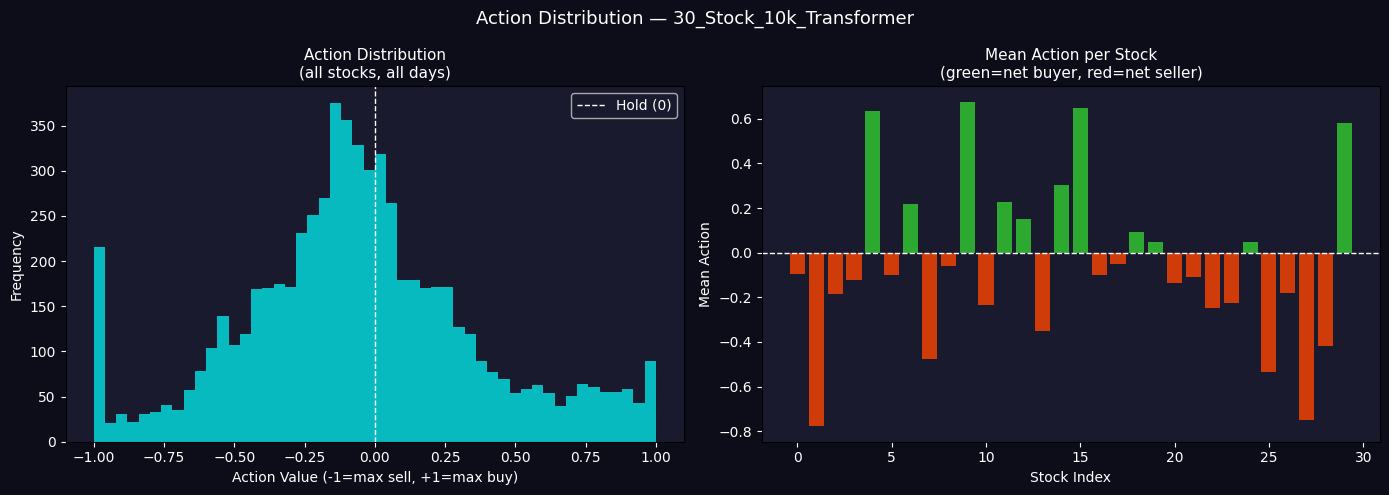

Buy-and-Hold: 30 stocks, $333 per stock

  BUY-AND-HOLD METRICS
  Total Return (%)               28.62
  Sharpe Ratio                   1.359
  Max Drawdown (%)               -10.1
  Win Rate (%)                   57.37
  Avg Daily Return (%)          0.1053
  Volatility (%)                 15.84
  Calmar Ratio                   2.833
  MARKET REGIME ANALYSIS

  H1 2024 — Bull Market (Jan-Jun):
  30_Stock_10k_Transformer                   Sharpe:  0.200  Return:    3.42%  MaxDD:  -12.14%  WinRate:  50.4%
  Buy-and-Hold                               Sharpe:  2.010  Return:   15.74%  MaxDD:   -6.35%  WinRate:  57.7%

  H2 2024 — Volatile (Jul-Dec):
  30_Stock_10k_Transformer                   Sharpe:  1.002  Return:    9.10%  MaxDD:  -10.65%  WinRate:  56.5%
  Buy-and-Hold                               Sharpe:  0.939  Return:   10.93%  MaxDD:  -10.10%  WinRate:  56.7%

  Full Period (Jan 2024 - Jan 2025):
  30_Stock_10k_Transformer                   Sharpe:  0.629  Return:   13.31%  MaxD

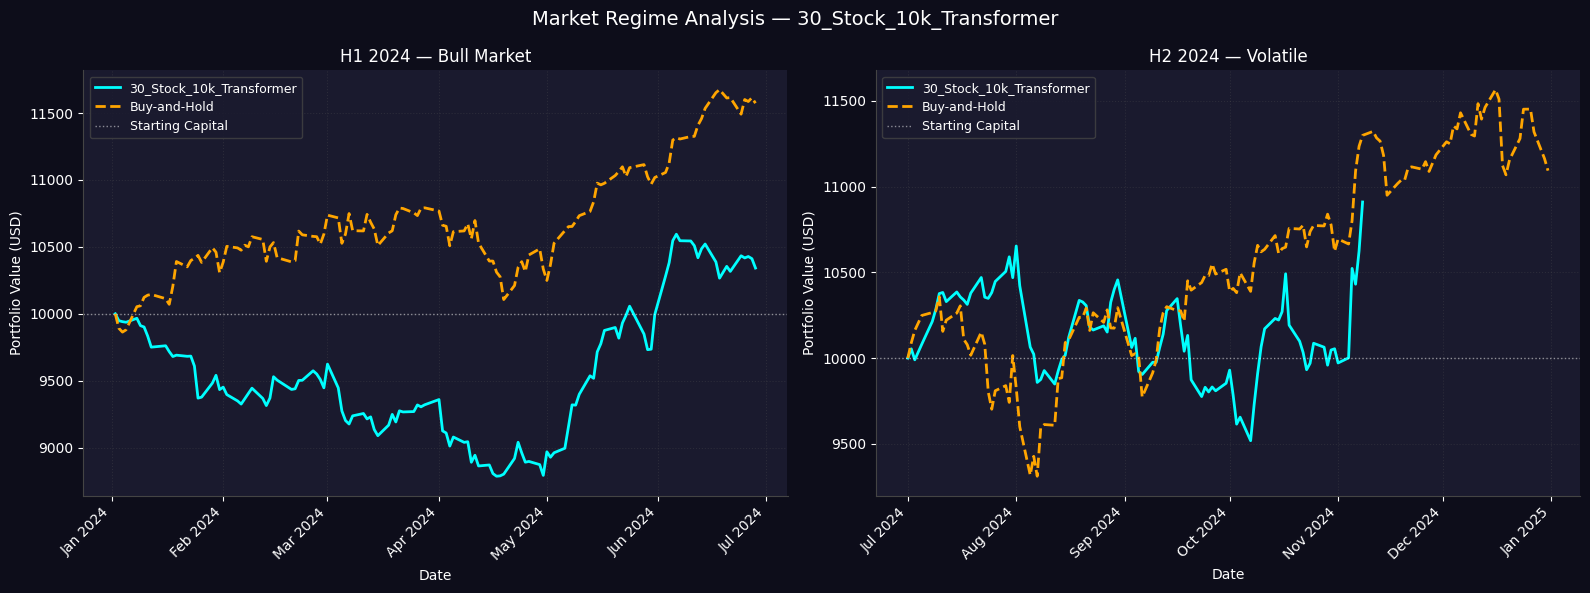

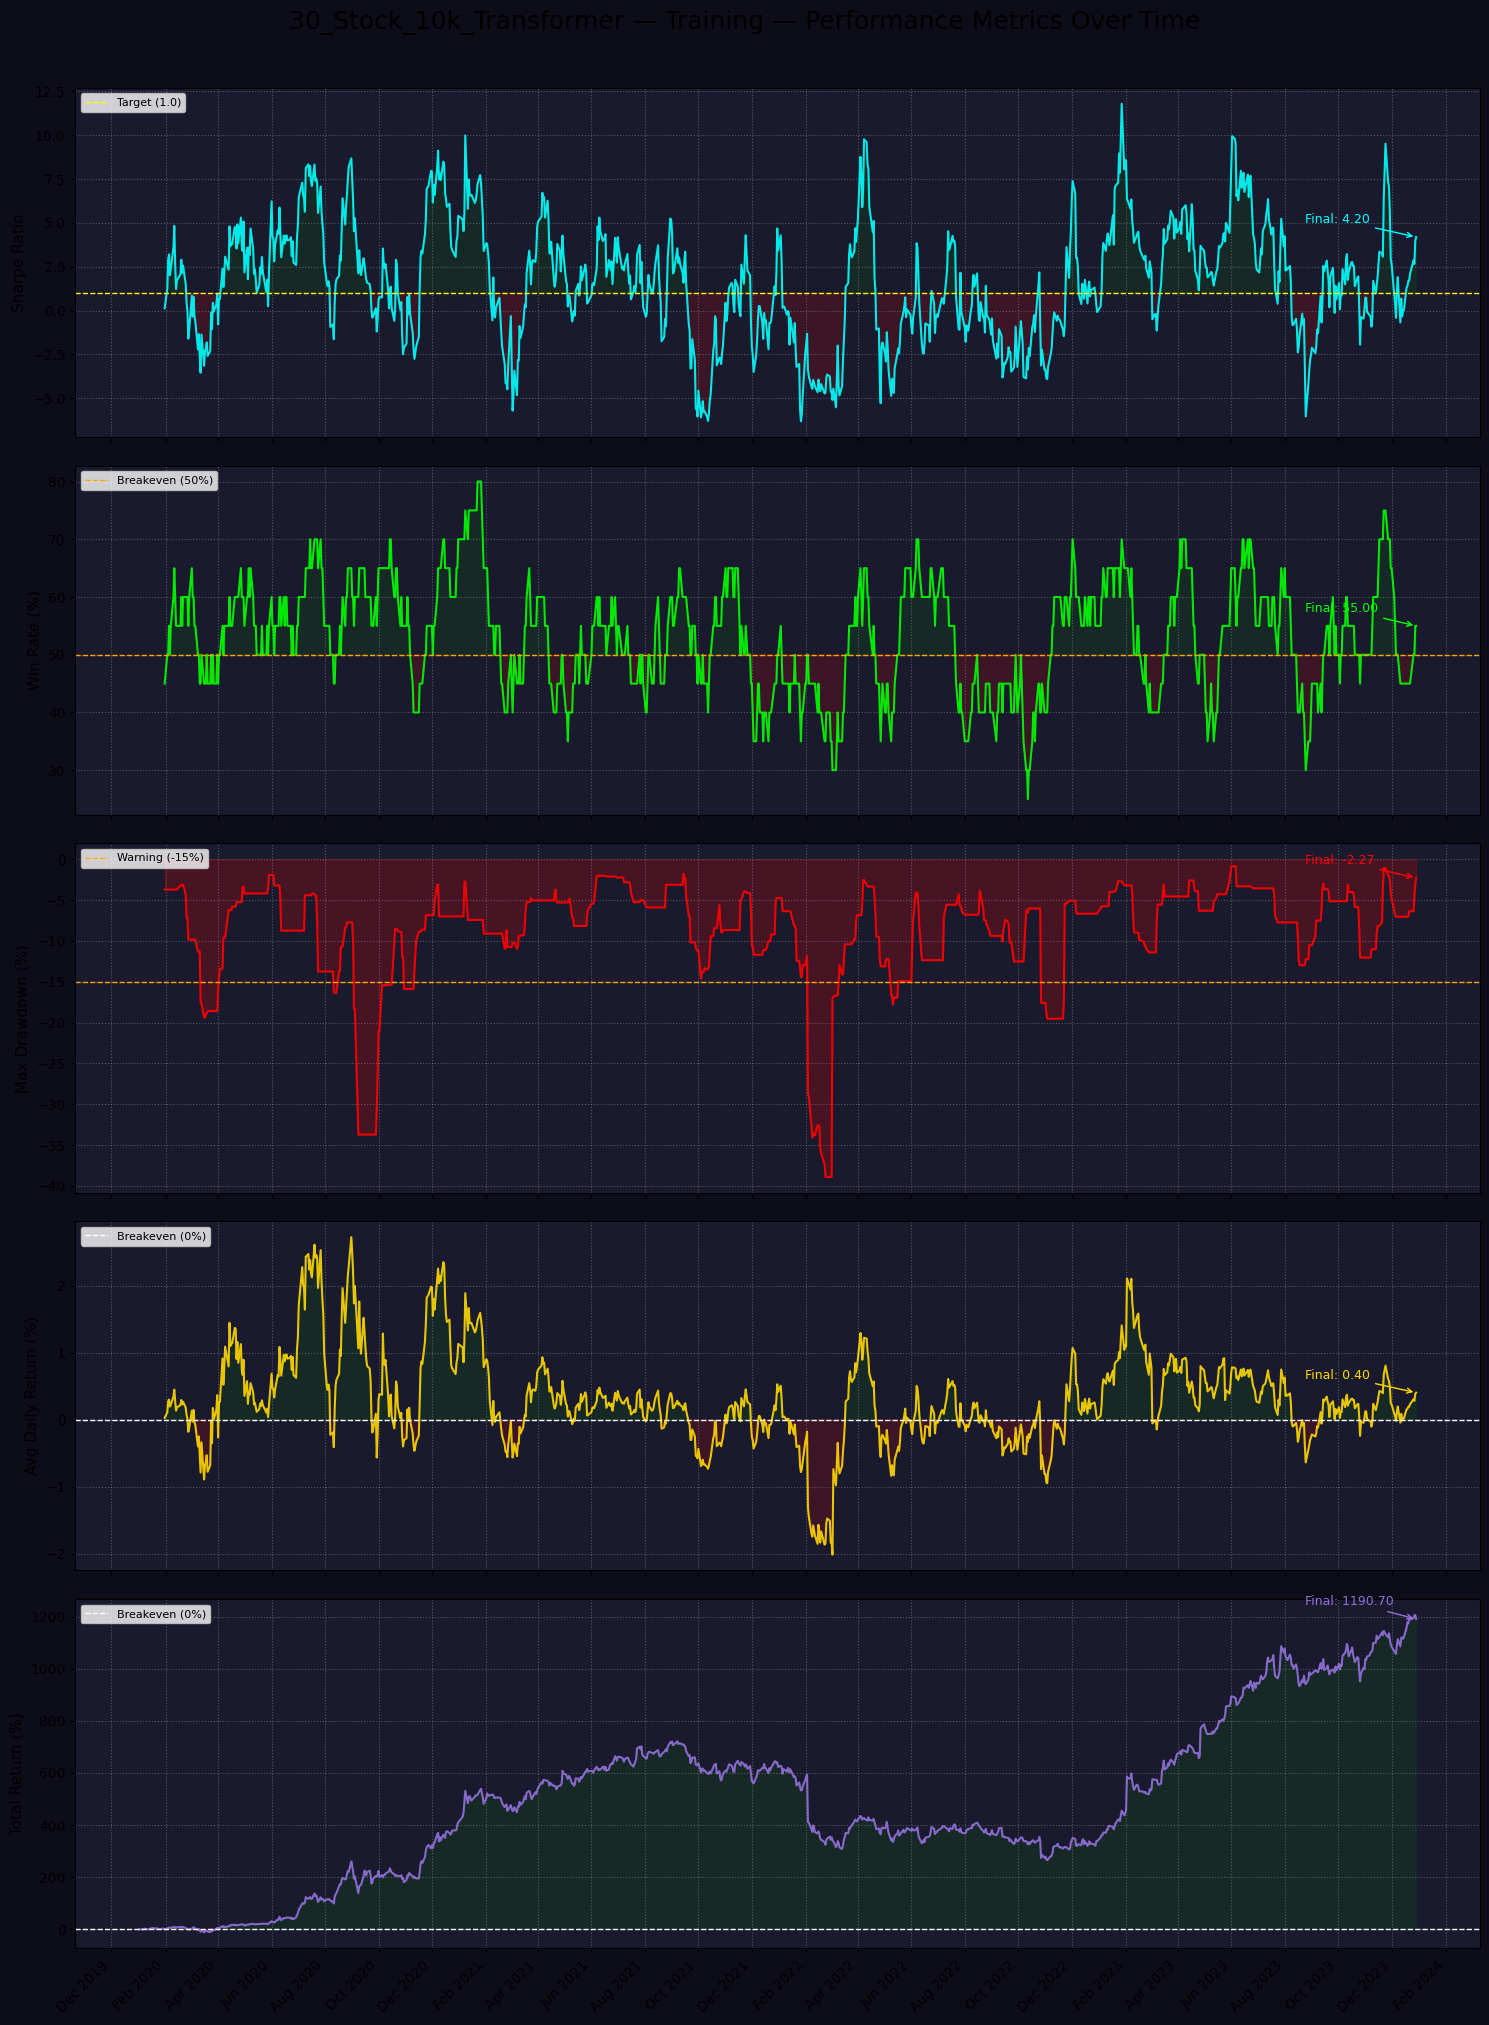


  30_STOCK_10K_TRANSFORMER — TRAINING — FINAL METRIC VALUES
  Sharpe Ratio                   1.587  (avg)
  Win Rate (%)                  52.992  (avg)
  Max Drawdown (%)              -8.830  (avg)
  Avg Daily Return (%)           0.302  (avg)
  Total Return (%)            1190.698  (final)


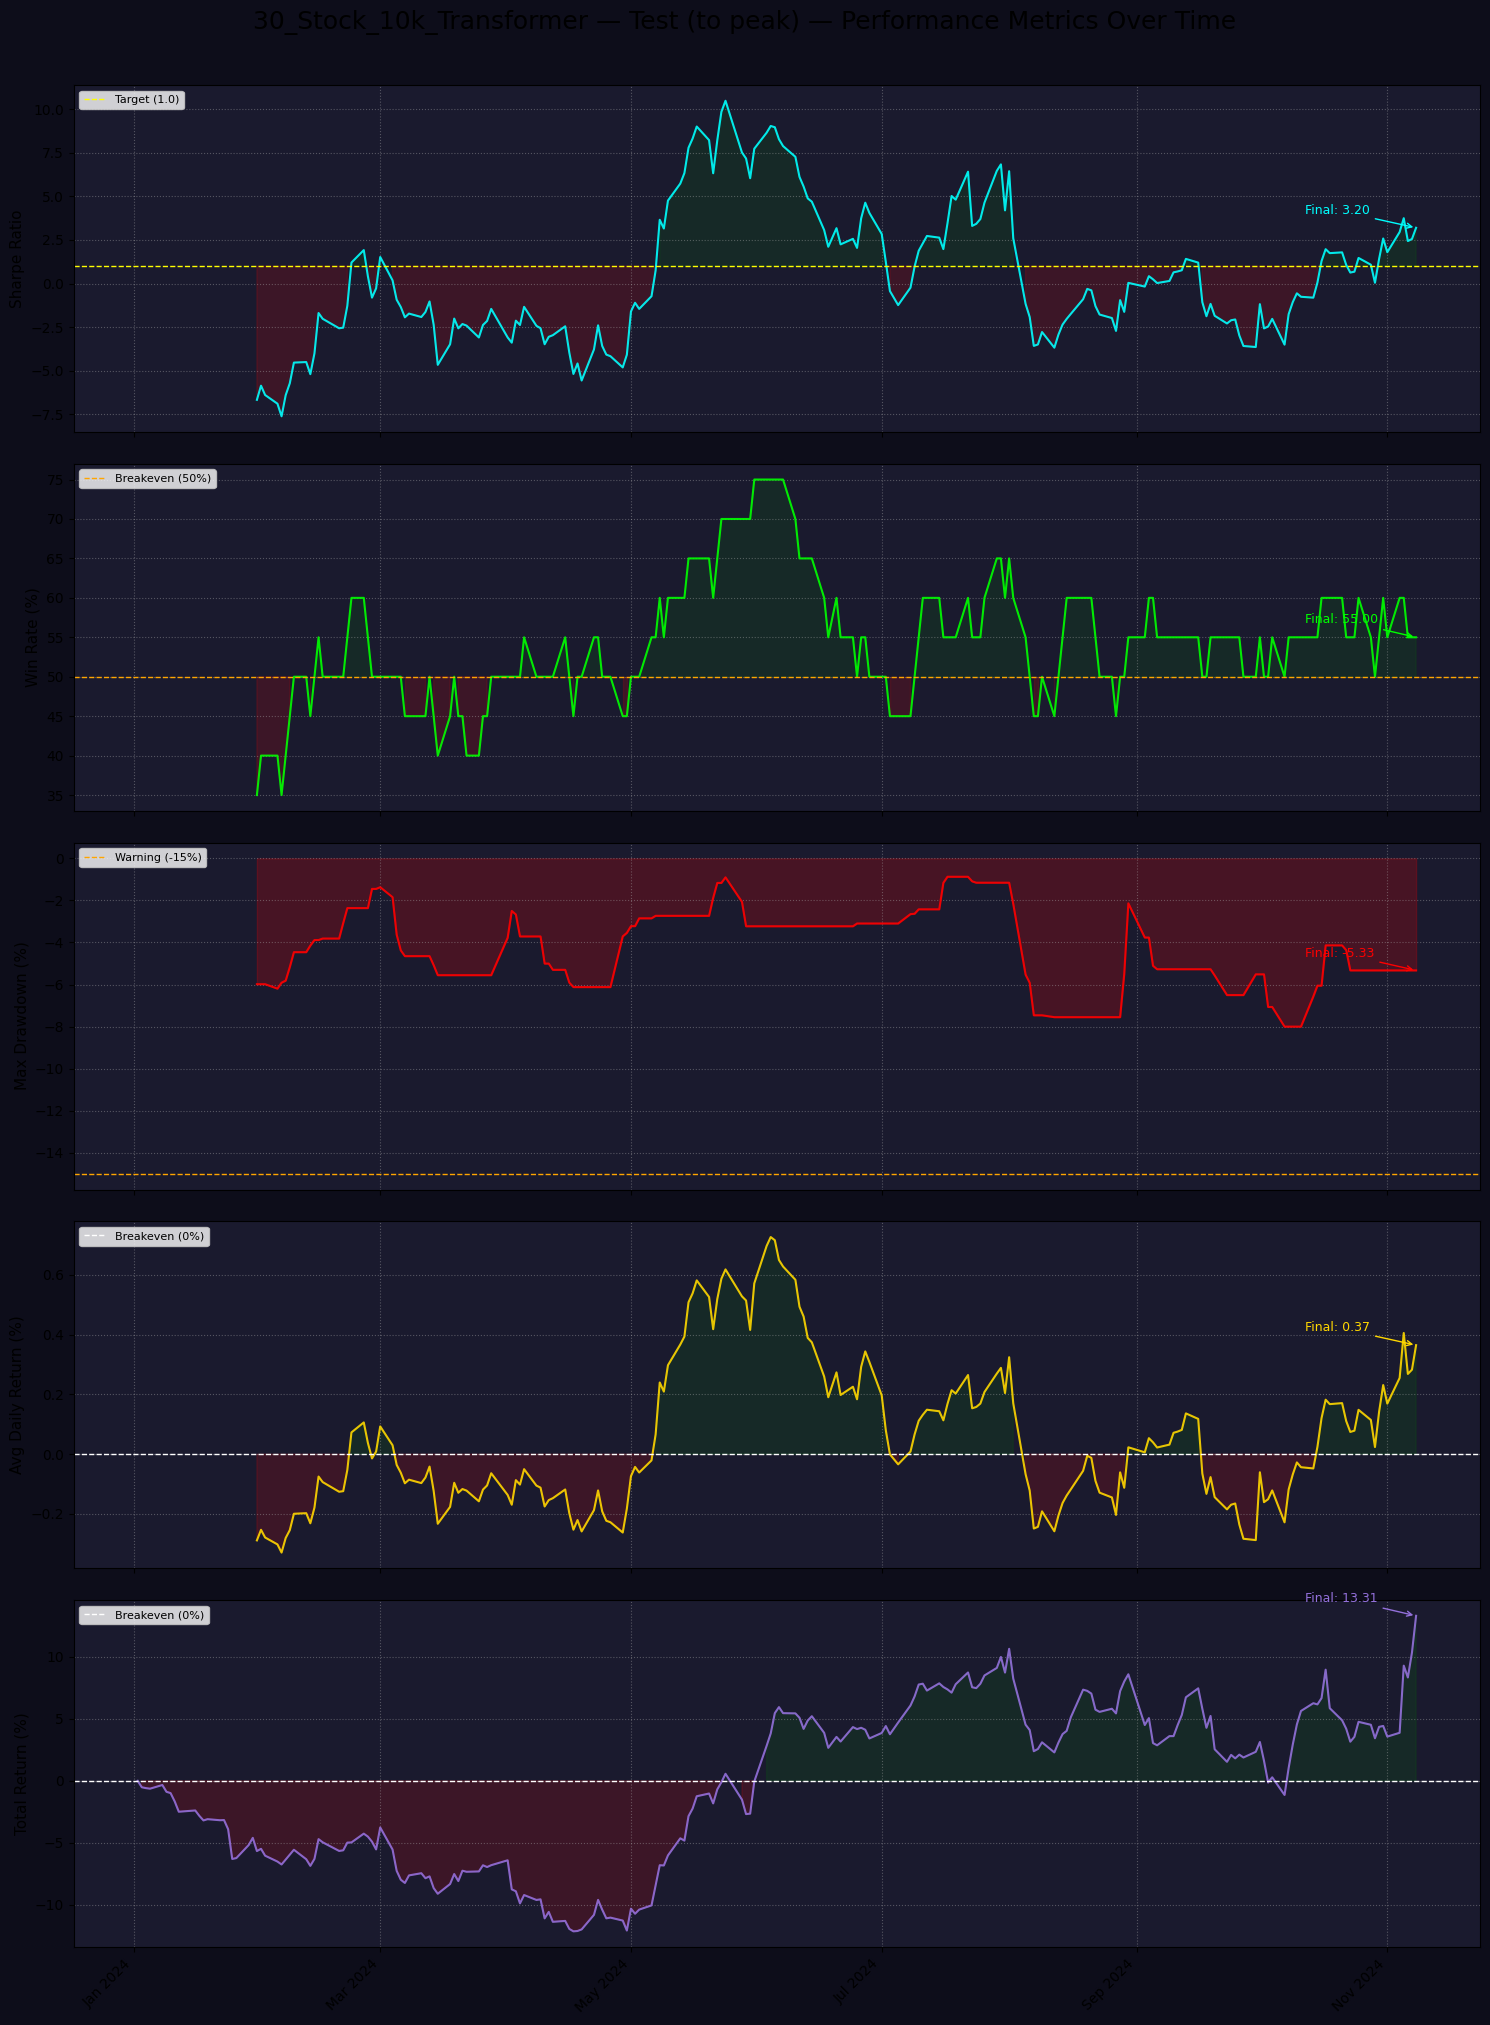


  30_STOCK_10K_TRANSFORMER — TEST (TO PEAK) — FINAL METRIC VALUES
  Sharpe Ratio                   0.346  (avg)
  Win Rate (%)                  54.264  (avg)
  Max Drawdown (%)              -4.396  (avg)
  Avg Daily Return (%)           0.049  (avg)
  Total Return (%)              13.312  (final)

Pkl files saved: 6 files
Metrics summary: ./overlay_data/30_Stock_10k_Transformer_metrics_summary.txt

  EVALUATION COMPLETE — 30_Stock_10k_Transformer



In [14]:
# ============================================================
# EVALUATION
# ============================================================

# Step 1 — Save VecNormalize immediately after training
env_train_norm.save("vec_normalize_30stocks_10k.pkl")
print("VecNormalize saved ✅")

# Step 2 — Load best model
trained_tfm = PPO.load(
    './best_train_sharpe_30stocks_10k/best_train_model',
    device='cpu'
)
trained_tfm.policy.to('cpu')
print("Best model loaded ✅")

# Step 3 — Run predictions
print("Running train prediction...")
df_train_account, _ = predict_with_sequence_env(
    trained_tfm, df_train,
    norm_path='vec_normalize_30stocks_10k.pkl'
)

print("Running test prediction...")
df_test_account, df_actions = predict_with_sequence_env(
    trained_tfm, df_test,
    norm_path='vec_normalize_30stocks_10k.pkl'
)

# Step 4 — Full evaluation
results = run_full_evaluation_transformer(
    df_train_account = df_train_account,
    df_test_account  = df_test_account,
    df_actions       = df_actions,
    df_test          = df_test,
    model_name       = 'Transformer',
    universe         = '30_Stock',    # ← change per notebook
    capital          = '10k',
    initial_capital  = 10_000,
)